# Assignment 2: Mastering Big Data Handling

#Setup and Introduction

*   Purpose: Briefly state the objective of this notebook (i.e., to implement and compare strategies for handling large datasets).
*   Libraries: Import all necessary Python libraries.




In [9]:
import pandas as pd
import numpy as np
import os
import dask.dataframe as dd
from IPython.display import display
import psutil
import time
import csv
import polars as pl
import threading
import seaborn as sns
import matplotlib.pyplot as plt
import time
import timeit
import threading
import tracemalloc
import gc

# **Task 1: Dataset Selection**

- **Name**: Amazon Books Reviews
- **Source**: [Kaggle - mohamedbakhet](https://www.kaggle.com/datasets/mohamedbakhet/amazon-books-reviews)
- **Domain**: Entertainment / Literature / User Reviews
- **File Size**: 2.86 GB
- **Structure**: 3,000,000 rows X 10 column

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"afiqdanial01","key":"610cc58bf72aba8a539970f1067d91ec"}'}

In [3]:

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [4]:
!kaggle datasets download -d mohamedbakhet/amazon-books-reviews

Dataset URL: https://www.kaggle.com/datasets/mohamedbakhet/amazon-books-reviews
License(s): CC0-1.0
100% 1.06G/1.06G [00:13<00:00, 87.1MB/s]



In [5]:
!unzip amazon-books-reviews.zip

Archive:  amazon-books-reviews.zip
  inflating: Books_rating.csv        
  inflating: books_data.csv          


In [6]:
!ls


amazon-books-reviews.zip  Books_rating.csv  sample_data
books_data.csv		  kaggle.json


#**Task 2: Load and Inspect Data**

In [ ]:
df_copy = pd.read_csv("Books_rating.csv", low_memory=False)
df = df_copy.copy()
df.head()

,Id,Title,Price,User_id,profileName,review/helpfulness,review/score,review/time,review/summary,review/text
0,1882931173,Its Only Art If Its Well Hung!,NaN,AVCGYZL8FQQTD,"Jim of Oz ""jim-of-oz""",7/7,4.0,940636800,Nice collection of Julie Strain images,This is only for Julie Strain fans. It's a col...
1,0826414346,Dr. Seuss: American Icon,NaN,A30TK6U7DNS82R,Kevin Killian,10/10,5.0,1095724800,Really Enjoyed It,I don't care much for Dr. Seuss but after read...
2,0826414346,Dr. Seuss: American Icon,NaN,A3UH4UZ4RSVO82,John Granger,10/11,5.0,1078790400,Essential for every personal and Public Library,"If people become the books they read and if ""t..."
3,0826414346,Dr. Seuss: American Icon,NaN,A2MVUWT453QH61,"Roy E. Perry ""amateur philosopher""",7/7,4.0,1090713600,Phlip Nel gives silly Seuss a serious treatment,"Theodore Seuss Geisel (1904-1991), aka &quot;D..."
4,0826414346,Dr. Seuss: American Icon,NaN,A22X4XUPKF66MR,"D. H. Richards ""ninthwavestore""",3/3,4.0,1107993600,Good academic overview,Philip Nel - Dr. Seuss: American IconThis is b...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 10 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Id                  object 
 1   Title               object 
 2   Price               float64
 3   User_id             object 
 4   profileName         object 
 5   review/helpfulness  object 
 6   review/score        float64
 7   review/time         int64  
 8   review/summary      object 
 9   review/text         object 
dtypes: float64(2), int64(1), object(7)
memory usage: 228.9+ MB


In [ ]:
df.count()

,0
Id,3000000
Title,2999792
Price,481171
User_id,2438213
profileName,2438095
review/helpfulness,3000000
review/score,3000000
review/time,3000000
review/summary,2999593
review/text,2999992


In [ ]:
rows, cols = df.shape
print(f"Rows: {rows}, Columns: {cols}")

Rows: 3000000, Columns: 10


# **Task 3: Big Data Handling Strategies**

## 1. Load Less Data
Load only required columns or filter relevant rows during read operation.

In [ ]:
selected_columns = ["Title", "Price", "User_id", "review/score", "review/summary"]

# Before
df_full = pd.read_csv("Books_rating.csv")
mem_before = df_full.memory_usage(deep=True).sum()

# After - load only required columns
df_after = pd.read_csv("Books_rating.csv", usecols=selected_columns)
mem_after = df_after.memory_usage(deep=True).sum()

print(f"Before: {mem_before / (1024 ** 2):.2f} MB")
print(f"After:  {mem_after / (1024 ** 2):.2f} MB")
print(f"Saved:  {(mem_before - mem_after) / (1024 ** 2):.2f} MB")

Before: 3679.50 MB
After:  677.08 MB
Saved:  3002.41 MB


## 2. Chunking

Process the data in small chunks using pandas read_csv(chunksize=30000)

In [ ]:
start_time = time.time()

chunk_num = 0
total_rows = 0

for chunk in pd.read_csv("Books_rating.csv", chunksize=30000):
    chunk_num += 1
    total_rows += len(chunk)
    print(f"Chunk {chunk_num}: {len(chunk)} rows | Running total: {total_rows}")

end_time = time.time()
print(f"\nTotal chunks : {chunk_num}")
print(f"Total rows   : {total_rows}")
print(f"Execution Time taken   : {end_time - start_time:.2f} seconds")

Chunk 1: 30000 rows | Running total: 30000
Chunk 2: 30000 rows | Running total: 60000
Chunk 3: 30000 rows | Running total: 90000
Chunk 4: 30000 rows | Running total: 120000
Chunk 5: 30000 rows | Running total: 150000
Chunk 6: 30000 rows | Running total: 180000
Chunk 7: 30000 rows | Running total: 210000
Chunk 8: 30000 rows | Running total: 240000
Chunk 9: 30000 rows | Running total: 270000
Chunk 10: 30000 rows | Running total: 300000
Chunk 11: 30000 rows | Running total: 330000
Chunk 12: 30000 rows | Running total: 360000
Chunk 13: 30000 rows | Running total: 390000
Chunk 14: 30000 rows | Running total: 420000
Chunk 15: 30000 rows | Running total: 450000
Chunk 16: 30000 rows | Running total: 480000
Chunk 17: 30000 rows | Running total: 510000
Chunk 18: 30000 rows | Running total: 540000
Chunk 19: 30000 rows | Running total: 570000
Chunk 20: 30000 rows | Running total: 600000
Chunk 21: 30000 rows | Running total: 630000
Chunk 22: 30000 rows | Running total: 660000
Chunk 23: 30000 rows |

## 3. Optimized Data Type

Process the data in by convert the data  with specific data type


In [ ]:
df_mem = pd.read_csv("Books_rating.csv")

df_mem.info() # Before conversion

# Memory before
mem_before = df_mem.memory_usage(deep=True).sum()

# Downcast numeric columns
for col in df_mem.select_dtypes(include=["int64"]).columns:
    df_mem[col] = pd.to_numeric(df_mem[col], downcast="integer")

for col in df_mem.select_dtypes(include=["float64"]).columns:
    df_mem[col] = pd.to_numeric(df_mem[col], downcast="float")

# Convert low-cardinality string columns to category
for col in df_mem.select_dtypes(include=["object"]).columns:
    if df_mem[col].nunique() / len(df_mem) < 0.5:
        df_mem[col] = df_mem[col].astype("category")

# Memory after
mem_after = df_mem.memory_usage(deep=True).sum()

print(f"Before : {mem_before / (1024 ** 2):.2f} MB")
print(f"After  : {mem_after / (1024 ** 2):.2f} MB")
print(f"Saved  : {(mem_before - mem_after) / (1024 ** 2):.2f} MB  ({(mem_before - mem_after) / mem_before * 100:.1f}% reduction)")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 10 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Id                  object 
 1   Title               object 
 2   Price               float64
 3   User_id             object 
 4   profileName         object 
 5   review/helpfulness  object 
 6   review/score        float64
 7   review/time         int64  
 8   review/summary      object 
 9   review/text         object 
dtypes: float64(2), int64(1), object(7)
memory usage: 228.9+ MB
Before : 3679.50 MB
After  : 3026.93 MB
Saved  : 652.56 MB  (17.7% reduction)


In [ ]:
df_mem.info() # After datatype conversion

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 10 columns):
 #   Column              Dtype   
---  ------              -----   
 0   Id                  category
 1   Title               category
 2   Price               float32 
 3   User_id             category
 4   profileName         category
 5   review/helpfulness  category
 6   review/score        float32 
 7   review/time         int32   
 8   review/summary      object  
 9   review/text         object  
dtypes: category(5), float32(2), int32(1), object(2)
memory usage: 230.1+ MB


## 4. Sampling
Reduce the dataset size to reduce processing time

In [ ]:
# Stratified sampling - 10% sample
sample_df = df.sample(frac=0.1, random_state=42)

print(f"Original rows : {len(df)}")
print(f"Sampled rows  : {len(sample_df)}")

# Quick exploratory operation
print(sample_df.describe())

Original rows : 3000000
Sampled rows  : 300000
              Price   review/score   review/time
count  47902.000000  300000.000000  3.000000e+05
mean      21.800030       4.216783  1.132360e+09
std       25.325091       1.201380  1.491718e+08
min        1.000000       1.000000 -1.000000e+00
25%       10.840000       4.000000  1.000685e+09
50%       14.950000       5.000000  1.128384e+09
75%       23.950000       5.000000  1.268698e+09
max      716.630000       5.000000  1.362355e+09


In [ ]:
rows, cols = sample_df.shape
print(f"Rows: {rows}, Columns: {cols}")

Rows: 300000, Columns: 10


## 5. Parallel Processing with Dask and Polars

Processing parallel using dask and Polars (used multiple core).

Dask:

In [ ]:
start = time.time()

# Load CSV with Dask (lazy loading - doesn't read until computed)
ddf = dd.read_csv("Books_rating.csv", dtype={'Id': 'object'})

# Operation - compute mean of numeric columns
result = ddf.describe().compute()

mem_usage = ddf.memory_usage(deep=True).sum().compute()
end = time.time()

print(result)
print(f"\nMemory : {mem_usage / (1024 ** 2):.2f} MB")
print(f"Time   : {end - start:.2f} seconds")

               Price  review/score   review/time
count  481171.000000  3.000000e+06  3.000000e+06
mean       21.762656  4.215289e+00  1.132307e+09
std        26.206541  1.203054e+00  1.493202e+08
min         1.000000  1.000000e+00 -1.000000e+00
25%        11.960000  4.000000e+00  1.015459e+09
50%        18.160000  5.000000e+00  1.144627e+09
75%        39.250000  5.000000e+00  1.298851e+09
max       995.000000  5.000000e+00  1.362355e+09

Memory : 2877.83 MB
Time   : 100.76 seconds


Polars:

In [10]:
start = time.time()

# Load CSV with Polars
df = pl.read_csv("Books_rating.csv")

# Operation - compute mean of numeric columns individually
results = {
    "Price_mean"       : df["Price"].mean(),
    "review/score_mean": df["review/score"].mean(),
    "review/time_mean" : df["review/time"].mean()
}

mem_usage = df.estimated_size()
end = time.time()

print(f"Means  : {results}")
print(f"\nMemory : {mem_usage / (1024 ** 2):.2f} MB")
print(f"Time   : {end - start:.2f} seconds")

Means  : {'Price_mean': 21.76265587493845, 'review/score_mean': 4.215289333333334, 'review/time_mean': 1132306772.630393}

Memory : 2716.75 MB
Time   : 10.26 seconds


# Comparison Analytics

In [ ]:
# Compare measurement using a function
def measure_performance(func, description="", runs=3, *args, **kwargs):

    process   = psutil.Process(os.getpid())
    total_ram = psutil.virtual_memory().total / (1024 ** 2)

    # ── CPU tracking thread ───────────────────────────────────────────────
    cpu_samples = []
    done        = [False]

    def track_cpu():
        while not done[0]:
            cpu_samples.append(process.cpu_percent(interval=0.1))

    cpu_thread = threading.Thread(target=track_cpu)
    cpu_thread.start()

    # ── Memory ────────────────────────────────────────────────────────────
    mem_before_mb = process.memory_info().rss / (1024 ** 2)
    tracemalloc.start()

    # ── Execution Time ────────────────────────────────────────────────────
    run_times = []
    result    = None
    success   = True
    error_msg = ""

    for i in range(runs):
        t_start = time.time()
        try:
            result  = func(*args, **kwargs)
            success = True
        except Exception as e:
            result    = None
            success   = False
            error_msg = str(e)
            break
        t_end = time.time()
        run_times.append(round(t_end - t_start, 4))

    # ── Memory snapshot AFTER ─────────────────────────────────────────────
    _, peak_traced = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    mem_after_mb   = process.memory_info().rss / (1024 ** 2)
    done[0]        = True
    cpu_thread.join()

    # ── Derived values ────────────────────────────────────────────────────
    peak_memory_mb = peak_traced  / (1024 ** 2)
    mem_diff_mb    = mem_after_mb - mem_before_mb
    avg_time       = round(sum(run_times) / len(run_times), 4) if run_times else 0.0
    avg_cpu        = round(sum(cpu_samples) / len(cpu_samples), 2) if cpu_samples else 0.0

    performance = {
        "Description":                    description,
        "Memory Used (MB)":               round(mem_diff_mb,    2),
        "Peak Memory - tracemalloc (MB)": round(peak_memory_mb, 4),
        "Avg Execution Time (s)":         avg_time,
        "Average CPU (%)":                avg_cpu,
        "Success?":                       success,
    }

    if not success:
        performance["Error"] = error_msg

    return performance, result

## Library 1: Sample Load with Pandas


In [ ]:
def load_full_data():
    df = pd.read_csv("Books_rating.csv")
    df_sampled = df.sample(frac=0.1, random_state=42)
    return df_sampled

performance, df = measure_performance(load_full_data, description="Load with Pandas (10% sample)")

performance_df = pd.DataFrame([performance])
display(performance_df)

,Description,Memory Used (MB),Peak Memory - tracemalloc (MB),Avg Execution Time (s),Average CPU (%),Success
0,Load with Pandas (10% sample),1059.78,3928.5455,70.6697,110.28,True


## Library 2: Sample Load with Polars

In [ ]:
def load_with_polars(filepath):
    df = pl.read_csv(filepath)
    df_sampled = df.sample(fraction=0.1, seed=42)
    return df_sampled.to_pandas()

performance_polars, df_polars = measure_performance(
    load_with_polars,
    description="Load with Polars (10% sample)",
    filepath="Books_rating.csv"
)

performance_df = pd.DataFrame([performance_polars])
display(performance_df)

,Description,Memory Used (MB),Peak Memory - tracemalloc (MB),Avg Execution Time (s),Average CPU (%),Success
0,Load with Polars (10% sample),4987.64,573.3536,10.01,157.79,True


## Library 3: Sample Load with Dask


In [ ]:
def load_full_data_dask_and_compute(file_path):
    # Dask setup
    ddf = dd.read_csv(
        file_path,
        assume_missing=True,
        quoting=3,
        on_bad_lines='skip',
        dtype=str
    )

    # Trigger computation and return the pandas DataFrame
    df = ddf.compute()
    df_sampled = df.sample(frac=0.1, random_state=42)
    return df_sampled

# Measure the performance of the loading and computation
performance_dask_compute, df_dask_computed = measure_performance(
    load_full_data_dask_and_compute,
    description="Load with Dask (10% sample)",
    file_path="Books_rating.csv"
)

performance_df_compute = pd.DataFrame([performance_dask_compute])
display(performance_df_compute)

,Description,Memory Used (MB),Peak Memory - tracemalloc (MB),Avg Execution Time (s),Average CPU (%),Success
0,Load with Dask (10% sample),2937.39,1339.2336,184.4054,116.8,True


# **Comparative Analysis**

## Comparison Chart

We use seaborn and matplotib to plot the diagram to compare performance three types of libraries (Pandas, Dask and Polars). Note that we use 10% sample of actual dataset since it was incapable to do full load on Polars library and we want to compare fairly with others libraries too.

/tmp/ipykernel_4407/3763611438.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
/tmp/ipykernel_4407/3763611438.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
/tmp/ipykernel_4407/3763611438.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
/tmp/ipykernel_4407/3763611438.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)


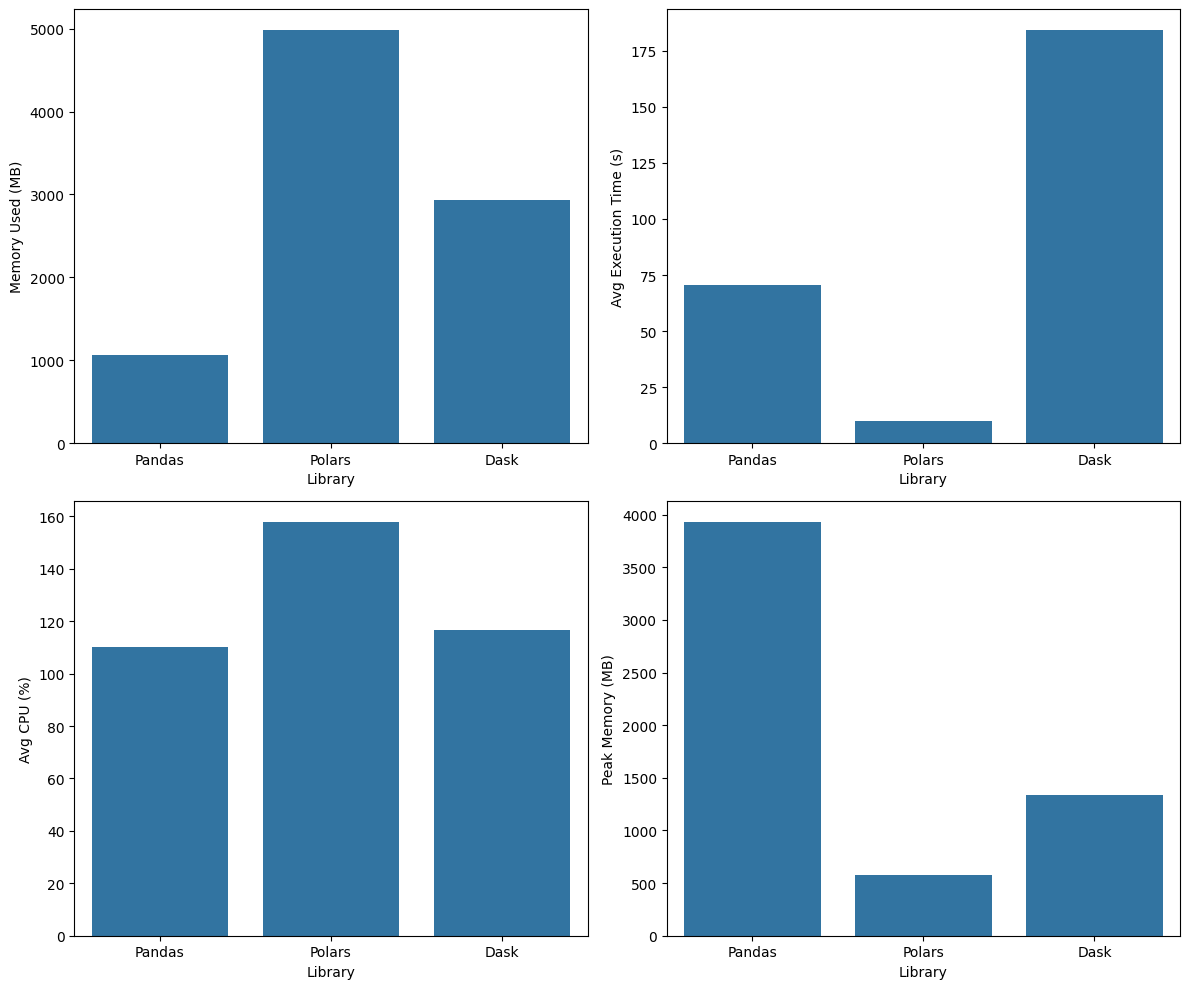

In [ ]:
library_data = pd.DataFrame({
    'Library': ['Pandas', 'Polars', 'Dask'],
    'Memory Used (MB)': [1059.78, 4987.64, 2937.39],
    'Peak Memory (MB)': [3928.5455, 573.3536, 1339.2336],
    'Avg Execution Time (s)': [70.6697	, 10.01, 184.4054],
    'Avg CPU (%)': [110.28, 157.79, 116.8]
})

# Bar plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.barplot(x="Library", y="Memory Used (MB)", data=library_data, ax=axes[0, 0])
sns.barplot(x="Library", y="Peak Memory (MB)", data=library_data, ax=axes[1, 1])
sns.barplot(x="Library", y="Avg Execution Time (s)", data=library_data, ax=axes[0, 1])
sns.barplot(x="Library", y="Avg CPU (%)", data=library_data, ax=axes[1, 0])

for ax in axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## Comparison Table

| Library | Memory Used (MB) | Peak Memory (MB) | Avg Execution Time (s) | Avg CPU (%) |
|---------|-----------------|-----------------|----------------------|-------------|
| Pandas  | 1059.78         | 3928.5455        | 70.6697              | 110.28      |
| Polars  | 4987.64         | 573.3536         | 10.01                | 157.79      |
| Dask    | 2937.39         | 1339.2336        | 184.4054             | 116.80      |